In [1]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
import sys
sys.path.append('..')
from src.utils import * 


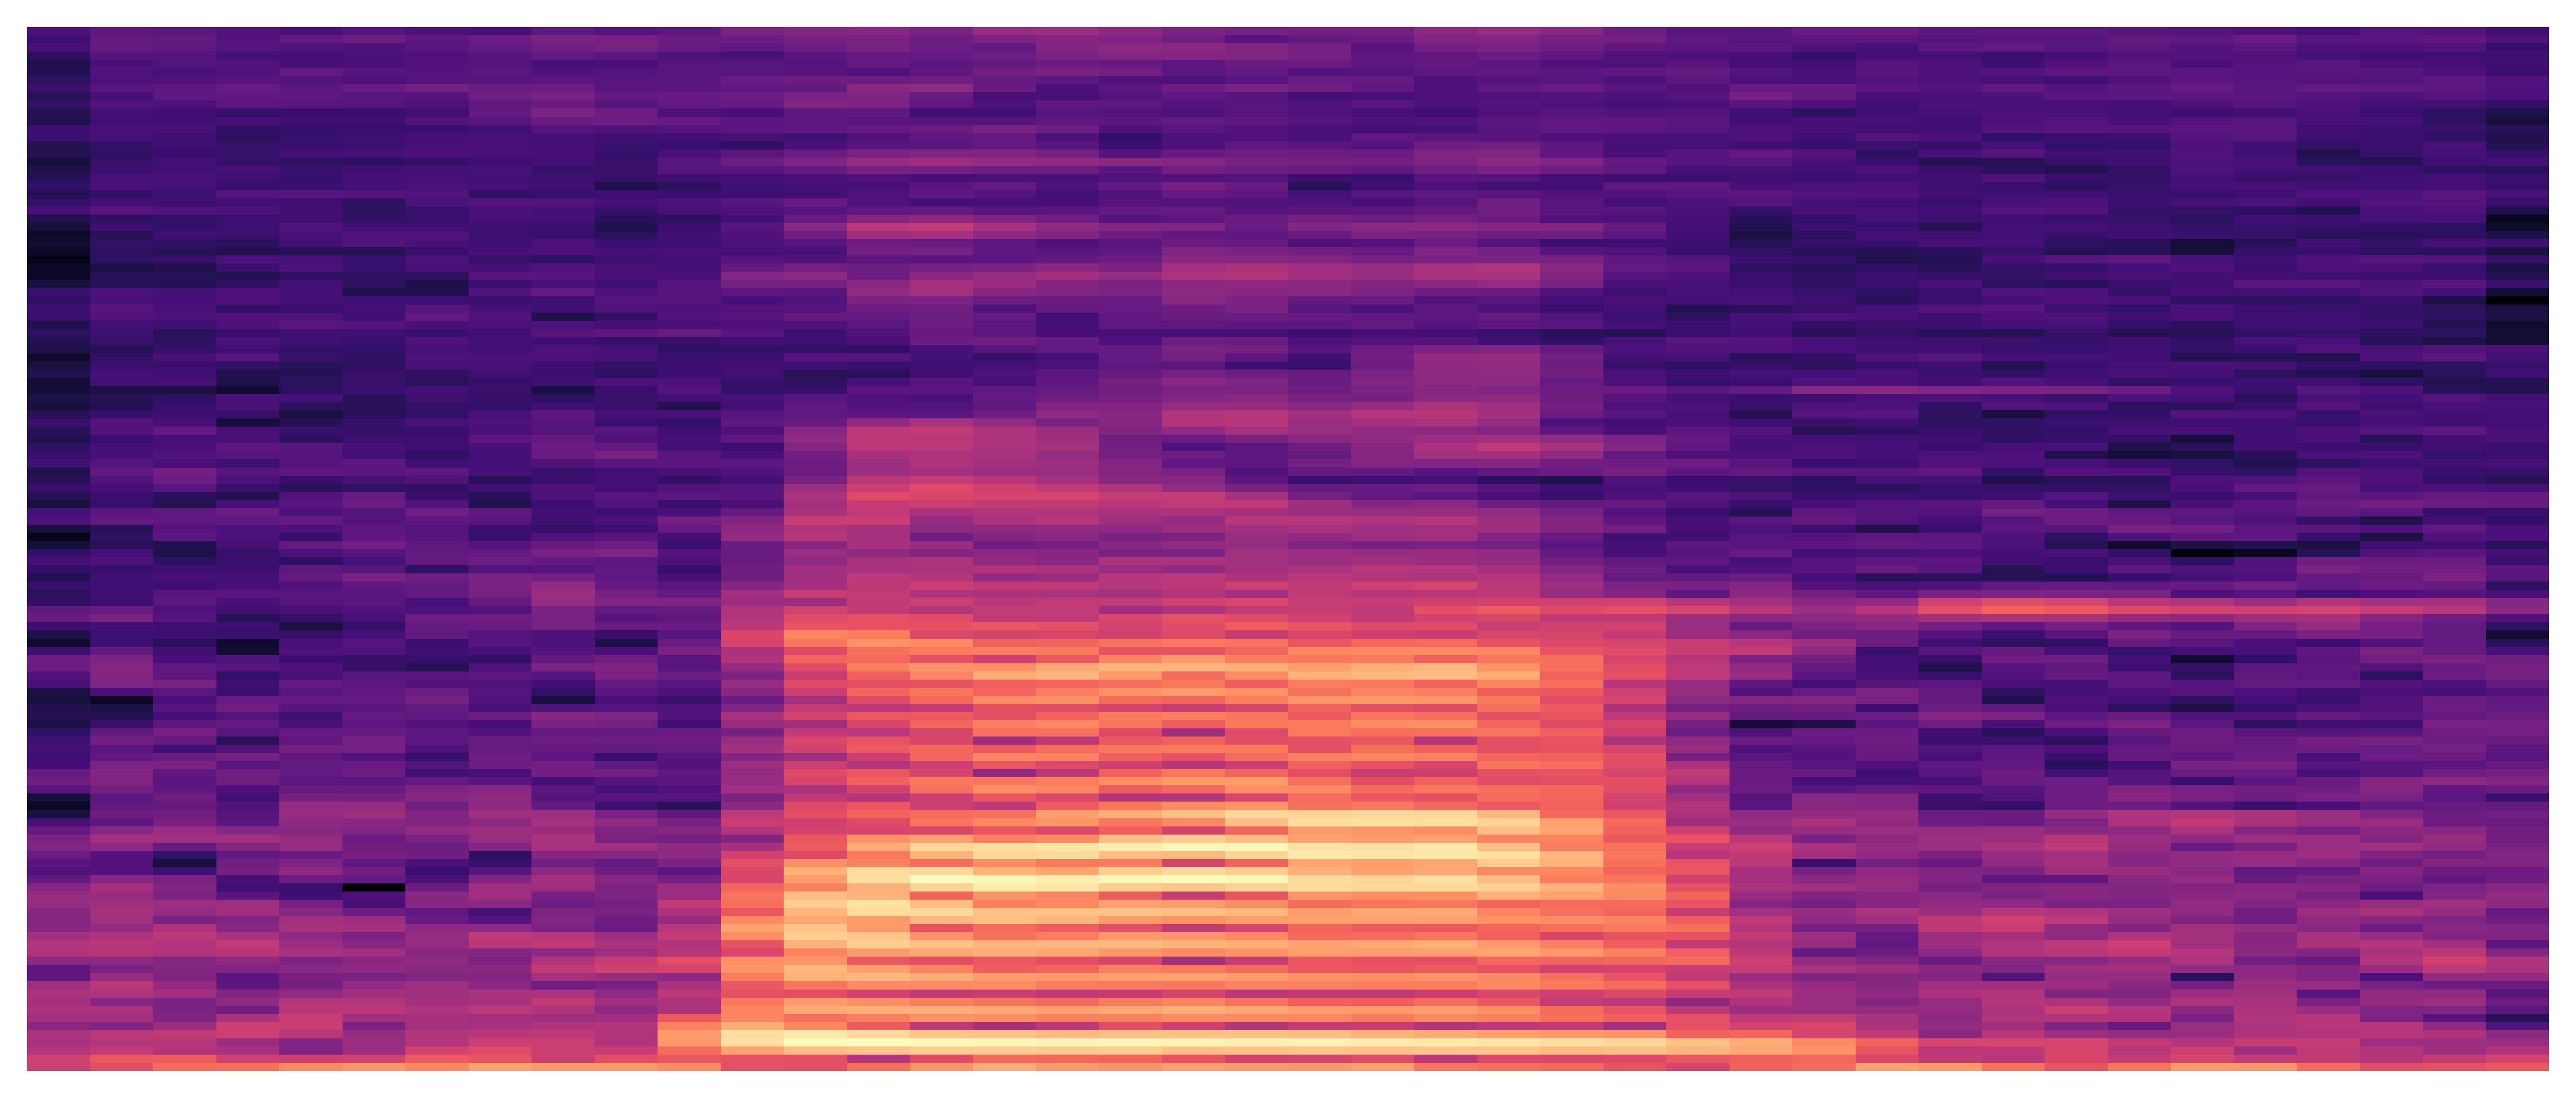

In [2]:
# TODO: remove wav file from repo (privacy concerns)
PATH_TO_WAV = r"../data/raw/allblocks.wav"

t_start = 304.5
t_end = 305
export_spectrogram(PATH_TO_WAV, t_start, t_end, "../figures/figure1/S26_gak_spectogramNov24_1.svg")

1.6000000000000227
0.8999999999999773


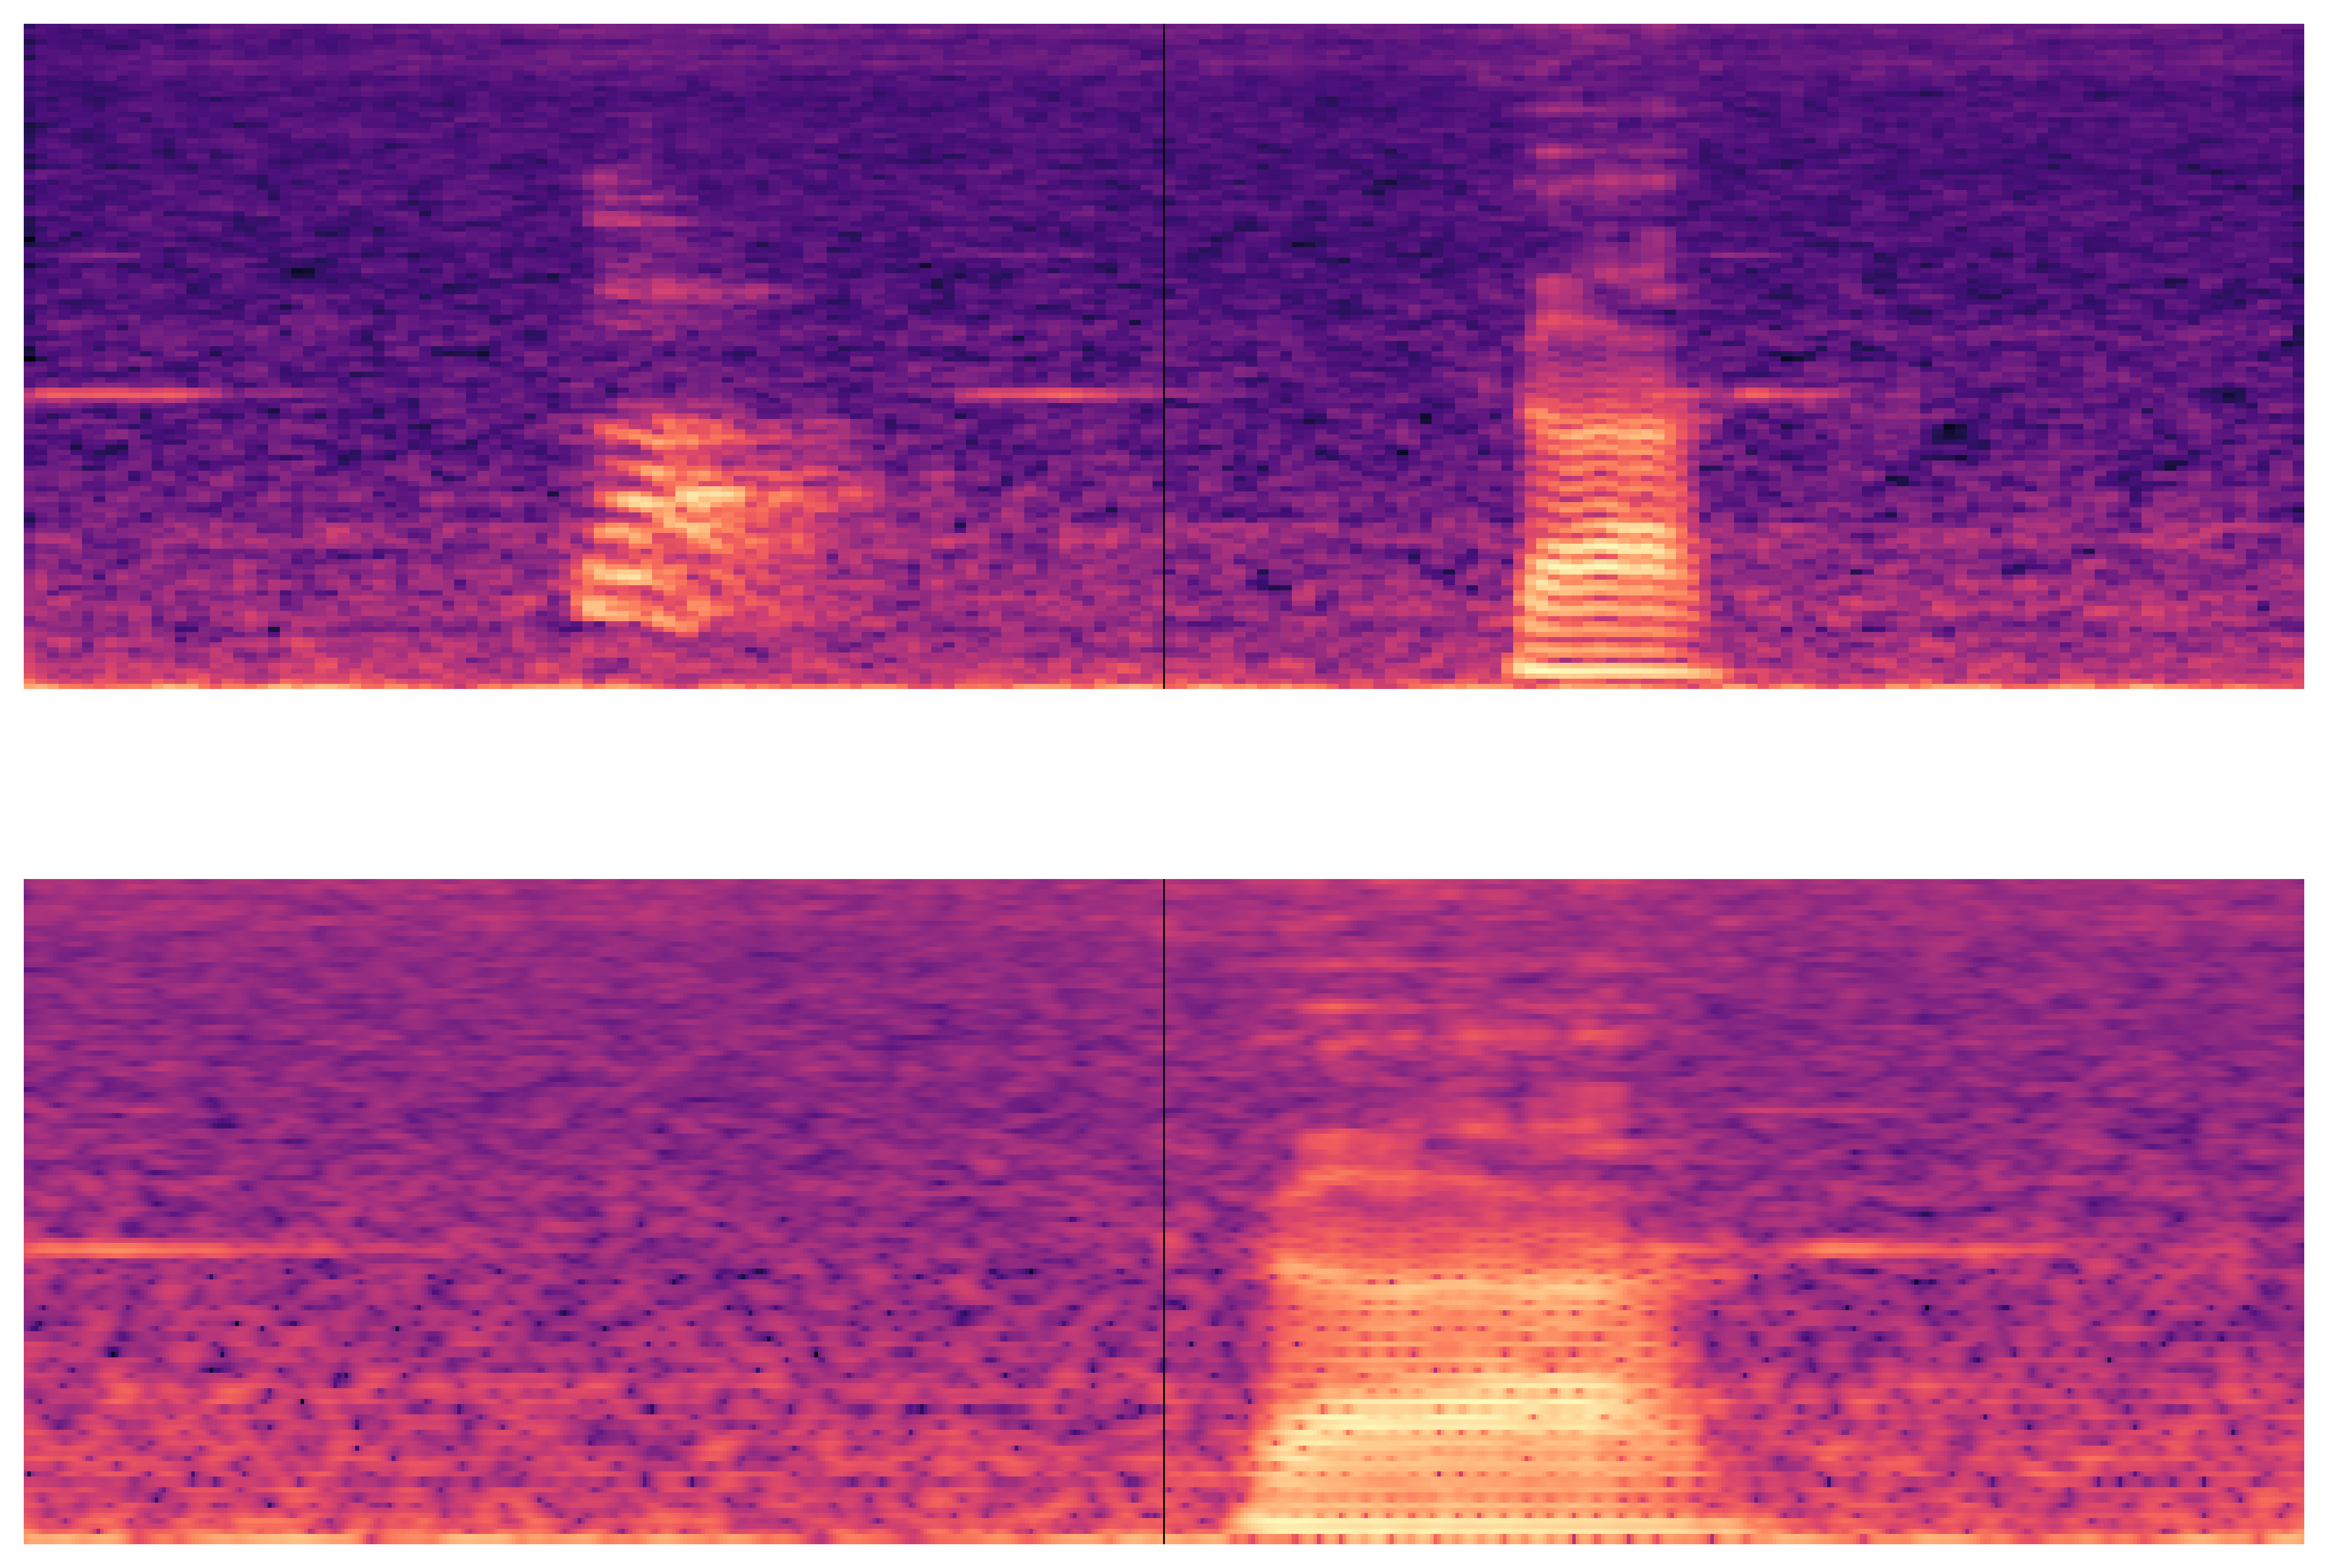

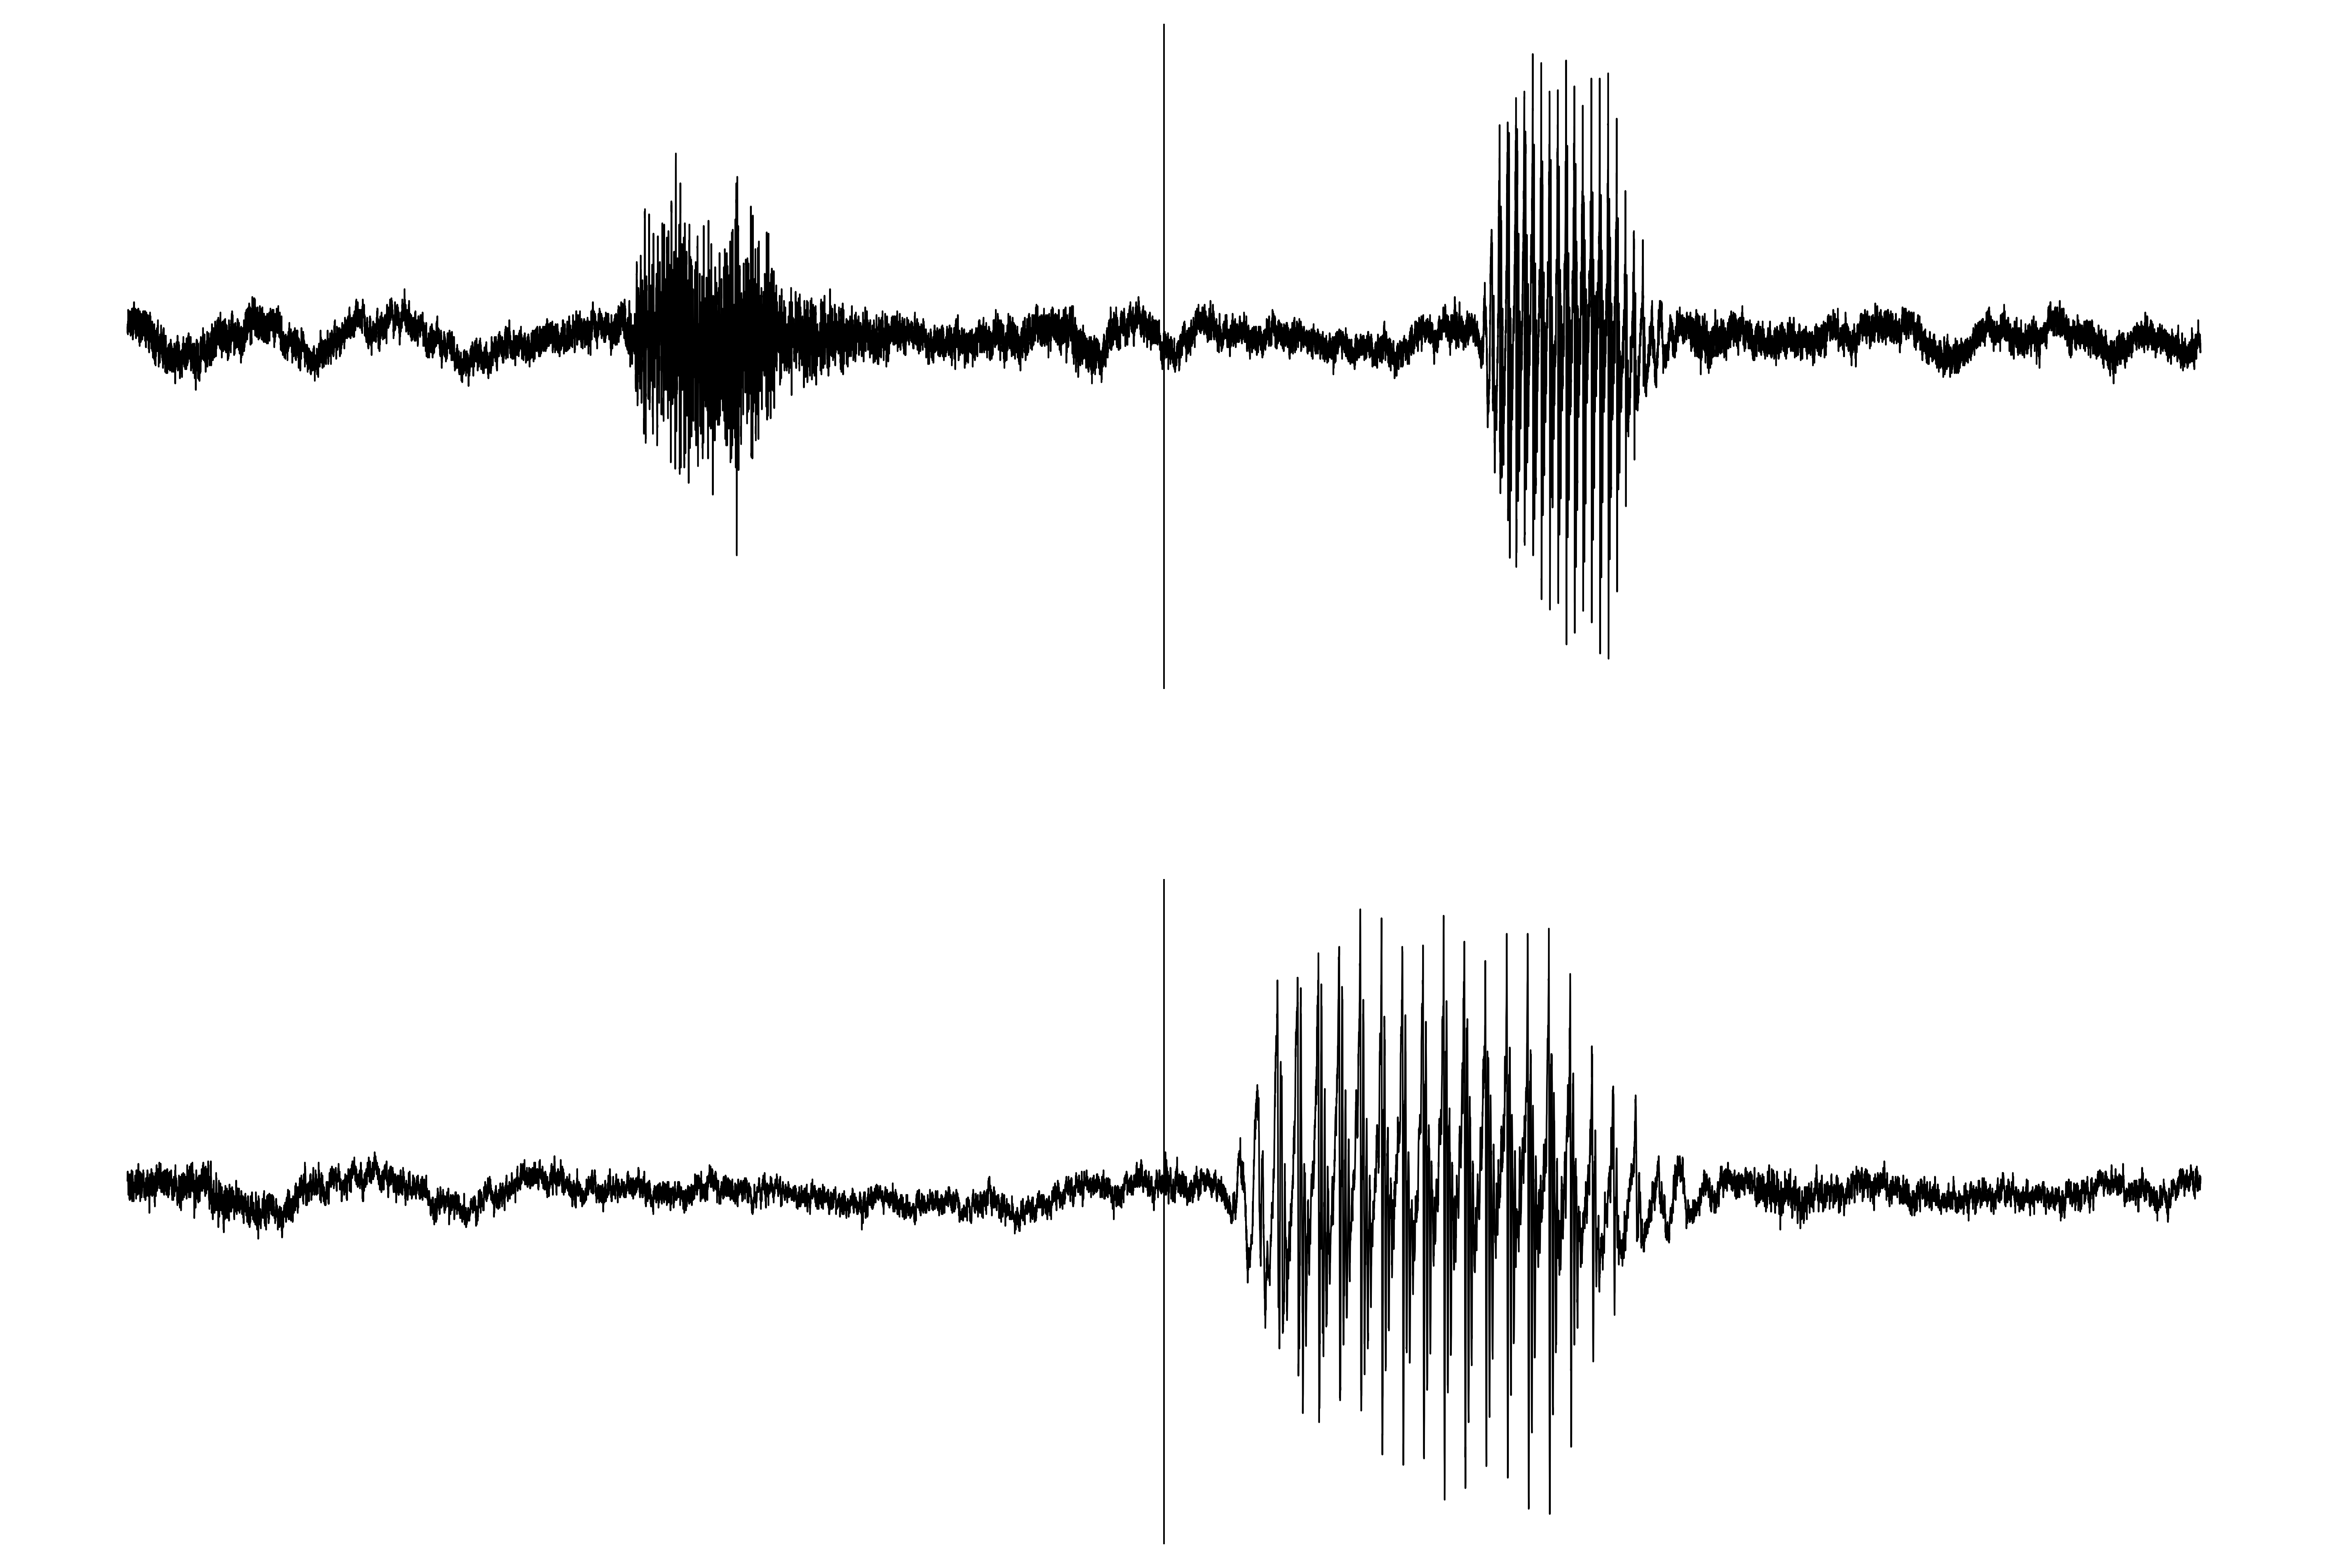

In [3]:
# These numbers were obtained via manual inspection of wav files in Audacity. 
print(304.6 - 303)
print(305.5 - 304.6)
t_start = 303
t_end = 305.5

t_zoom_s = 304.6 - 0.5
t_zoom_e = 304.6 + 0.5  

fig = export_spectrogram_with_zoom(PATH_TO_WAV, t_start, t_end, t_zoom_s, t_zoom_e, "../figures/figure1/S26_gak_spectogram_2panels_Nov24_1secaround.svg")
fig2 = export_waveform_with_zoom(PATH_TO_WAV, t_start, t_end, t_zoom_s, t_zoom_e, "../figures/figure1/S26_gak_waveform_2panels_Nov24_1secaround.svg")

# Trace

In [5]:
import scipy.io
data = scipy.io.loadmat('../figures/figure1/HG_P1_fulldata.mat')
data_P1 = data['data_P1']  # shape: (channels, trials, time)

In [ ]:
display(data_P1.shape) 
# what is the channel we need? answer: 97 (visual inspection)
# trial? 59 or 9 (also visual inspection)

(111, 148, 540)

In [11]:
time = np.linspace(-1.6, 0.9,data_P1.shape[2])

In [14]:
fig = go.Figure()

for tr in range(data_P1.shape[0]):
    fig.add_trace(
    go.Scatter(
        x=time, y=data_P1[tr, 97, :], 
        mode='lines', name=tr
        ))
    fig.update_xaxes(title_text="Time [ms]", showline=True, linecolor='black', linewidth=1,
                     ticks='outside', showticklabels=True)
    fig.update_yaxes(title_text="HG Power", showline=True, linecolor='black', linewidth=1,
                     ticks='outside', showticklabels=True)
    fig.update_layout(
        title=f"HG Response", 
        font=dict(family="Arial", size=10))
fig.show()

In [15]:
fig = go.Figure()

fig.add_trace(
go.Scatter(
    x=time, y=data_P1[91, 97, :], 
    mode='lines', name=tr
    ))
fig.update_xaxes(title_text="Time [ms]", showline=True, linecolor='black', linewidth=1,
                    ticks='outside', showticklabels=True)
fig.update_yaxes(title_text="HG Power", showline=True, linecolor='black', linewidth=1,
                    ticks='outside', showticklabels=True)
fig.update_layout(
    title=f"HG Response in trial {91}", 
    font=dict(family="Arial", size=10))
fig.show()

In [18]:
mm_to_px = 300 / 25.4
width_px = int(71.454 * mm_to_px)   # = 843
height_px = int(19.52 * mm_to_px)   # = 230

fig = go.Figure()

fig.add_trace(
go.Scatter(
    x=time, y=data_P1[39, 97, :], 
    mode='lines', name=tr
    ))
fig.update_xaxes(title_text="Time [ms]", showline=True, linecolor='black', linewidth=1,
                    ticks='outside', showticklabels=True)
fig.update_yaxes(title_text="HG Power", showline=True, linecolor='black', linewidth=1,
                    ticks='outside', showticklabels=True)
fig.update_layout(
    title=f"HG Response in trial {39}", 
    font=dict(family="Arial", size=10), 
    width=width_px, height= height_px)
fig.write_image(rf"../figures/figure1/neural_trace_tr_39.svg", format='svg', scale=3)
fig.show()